# TurboQuant (PyTorch, batched, KV-cache friendly)

PyTorch port of `turboquant.ipynb`. Differences:

- Every encode/decode is **batched** over arbitrary leading dims; the last axis is the feature dim. So a tensor shaped `[B, H, T, D]` flows through unchanged.
- A `TurboQuantKVCache` class wraps the quantizers and exposes a minimal `update` / `attention` API that drops into a transformer decode loop.
- Keys are stored with `TurboQuant` (used for `Q @ K^T` via inner-product estimation, no dequantization), values are stored with `PolarQuant` (dequantized for `attn @ V`).

In [1]:
import math
from dataclasses import dataclass

import numpy as np
import torch
import torch.nn.functional as F
from scipy.stats import norm as gaussian

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

DTYPE = torch.float32
print(f"device={DEVICE}, dtype={DTYPE}")

device=mps, dtype=torch.float32


## Lloyd-Max codebook

Same Lloyd-Max iteration as the numpy version (run on host once). Boundaries and centroids are stored as torch tensors on the target device so quantize/dequantize stay on-device for any input shape.

In [2]:
class LloydMaxCodebook:
    """Lloyd-Max codebook for unit Gaussian. quantize/dequantize work on tensors of any shape."""

    def __init__(self, bits: int, tol: float = 1e-8, device=None, dtype=torch.float32):
        assert 1 <= bits <= 6, "bits must be in [1, 6]"
        self.bits = bits
        self.tol = tol
        self.k = 2 ** bits
        self.device = device
        self.dtype = dtype

        boundaries = np.concatenate([[-np.inf],
                                     [gaussian.ppf(i / self.k) for i in range(1, self.k)],
                                     [np.inf]])
        centroids = self._centroids_np(boundaries)
        while True:
            old = boundaries.copy()
            boundaries = self._boundaries_np(centroids)
            centroids = self._centroids_np(boundaries)
            if np.max(np.abs(boundaries[1:-1] - old[1:-1])) < tol:
                break

        self.distortion = float(self._distortion_np(boundaries, centroids))
        self.boundaries = torch.from_numpy(boundaries).to(device=device, dtype=dtype)
        self.centroids = torch.from_numpy(centroids).to(device=device, dtype=dtype)
        self._interior = self.boundaries[1:-1].contiguous()

    @staticmethod
    def _centroids_np(b):
        out = []
        for b1, b2 in zip(b[:-1], b[1:]):
            out.append((gaussian.pdf(b1) - gaussian.pdf(b2)) / (gaussian.cdf(b2) - gaussian.cdf(b1)))
        return np.array(out)

    @staticmethod
    def _boundaries_np(c):
        out = [-np.inf]
        for c1, c2 in zip(c[:-1], c[1:]):
            out.append((c1 + c2) / 2)
        out.append(np.inf)
        return np.array(out)

    @staticmethod
    def _distortion_np(b, c):
        acc = 0.0
        for b1, b2, ci in zip(b[:-1], b[1:], c):
            p = gaussian.cdf(b2) - gaussian.cdf(b1)
            acc += p * ci * ci
        return 1.0 - acc

    def quantize(self, x: torch.Tensor) -> torch.Tensor:
        idx = torch.searchsorted(self._interior, x.contiguous())
        return idx.to(torch.uint8) if self.bits <= 8 else idx.to(torch.int16)

    def dequantize(self, idx: torch.Tensor) -> torch.Tensor:
        return self.centroids[idx.long()]

    def __repr__(self):
        return f"LloydMaxCodebook(bits={self.bits}, k={self.k}, distortion={self.distortion:.4f})"

In [3]:
# sanity: torch quantize on a batched tensor matches numpy quantize element-wise
cb = LloydMaxCodebook(bits=4, device=DEVICE, dtype=DTYPE)
print(cb)

x = torch.randn(3, 5, 16, device=DEVICE, dtype=DTYPE)
x_q = cb.quantize(x)
x_hat = cb.dequantize(x_q)
print("x.shape", x.shape, "-> idx.shape", x_q.shape, "dtype", x_q.dtype)
print("per-coord MSE:", (x - x_hat).pow(2).mean().item(), "   theory ~", cb.distortion)

LloydMaxCodebook(bits=4, k=16, distortion=0.0095)
x.shape torch.Size([3, 5, 16]) -> idx.shape torch.Size([3, 5, 16]) dtype torch.uint8
per-coord MSE: 0.008772804401814938    theory ~ 0.009501008008192313


## PolarQuant (batched)

Per-vector polar decomposition: store the norm in fp32 and quantize the unit vector after a Haar-random rotation (rotated coordinates are approximately N(0, 1/d), rescaled to N(0, 1) for the codebook).

All batch/head/sequence dims pass through transparently; only the last axis is treated as the feature dim.

In [4]:
def _haar_orthogonal(d: int, seed: int | None, device, dtype) -> torch.Tensor:
    g = torch.Generator(device="cpu")
    if seed is not None:
        g.manual_seed(seed)
    A = torch.randn(d, d, generator=g, dtype=torch.float64)
    Q, R = torch.linalg.qr(A)
    sign = torch.sign(torch.diagonal(R))
    return (Q * sign).to(device=device, dtype=dtype)


class PolarQuant:
    """Norm + Lloyd-Max indices on a Haar-rotated unit vector. Batched on last dim."""

    def __init__(self, bits: int, dim: int, tol: float = 1e-8,
                 seed: int | None = None, R: torch.Tensor | None = None,
                 device=None, dtype=torch.float32):
        self.bits = bits
        self.dim = dim
        self.device = device
        self.dtype = dtype
        self.sigma = 1.0 / math.sqrt(dim)
        self.codebook = LloydMaxCodebook(bits, tol, device=device, dtype=dtype)
        self.R = _haar_orthogonal(dim, seed, device, dtype) if R is None else R.to(device=device, dtype=dtype)

    def encode(self, x: torch.Tensor):
        """x: [..., D] -> (norms[...], indices[..., D] uint8)."""
        norms = x.norm(dim=-1, keepdim=True).clamp_min(1e-12)
        u = (x / norms) @ self.R.T
        idx = self.codebook.quantize(u / self.sigma)
        return norms.squeeze(-1), idx

    def decode_rotated(self, idx: torch.Tensor) -> torch.Tensor:
        """Reconstruction in rotated unit-sphere space (no norm applied)."""
        return self.codebook.dequantize(idx) * self.sigma

    def decode(self, norms: torch.Tensor, idx: torch.Tensor) -> torch.Tensor:
        u_hat = self.decode_rotated(idx)
        return norms.unsqueeze(-1) * (u_hat @ self.R)

In [5]:
# sanity: relative reconstruction error on uniform inputs across a batched tensor
torch.manual_seed(0)
B, H, T, D = 2, 4, 16, 1024
pq = PolarQuant(bits=4, dim=D, seed=42, device=DEVICE, dtype=DTYPE)

x = torch.empty(B, H, T, D, device=DEVICE, dtype=DTYPE).uniform_(-1, 1)
norms, idx = pq.encode(x)
x_hat = pq.decode(norms, idx)

rel_err = (x - x_hat).pow(2).sum(-1) / x.pow(2).sum(-1)
print(f"mean ||x - x_hat||^2 / ||x||^2 = {rel_err.mean().item():.4f}   theory ~{pq.codebook.distortion:.4f}")

mean ||x - x_hat||^2 / ||x||^2 = 0.0095   theory ~0.0095


## JL Quantizer (batched, with pairwise IP)

1-bit JL sketch: stores `rho = ||x||` and `sign(G x)`. Two estimators:

- `estimate_ip(rho, signs, y)` — element-wise inner-product estimate (matched leading dims).
- `estimate_ip_pairwise(rho, signs, y)` — every-key-vs-every-query estimate. Returns `[..., Q, K]`. This is what attention needs.

In [6]:
class JLQuantizer:
    """1-bit JL sketch for inner-product estimation."""

    def __init__(self, dim: int, m: int, seed: int | None = None,
                 device=None, dtype=torch.float32):
        self.dim = dim
        self.m = m
        self.device = device
        self.dtype = dtype
        g = torch.Generator(device="cpu")
        if seed is not None:
            g.manual_seed(seed)
        self.G = torch.randn(m, dim, generator=g, dtype=dtype).to(device=device)

    def encode(self, x: torch.Tensor):
        """x: [..., D] -> (rho[...], signs[..., m] int8 in {-1, +1})."""
        rho = x.norm(dim=-1)
        signs = torch.sign(x @ self.G.T)
        signs = torch.where(signs == 0, torch.ones_like(signs), signs)
        return rho, signs.to(torch.int8)

    def estimate_ip(self, rho: torch.Tensor, signs: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """Element-wise. signs:[...,m], y:[...,D] -> [...]."""
        gy = y @ self.G.T
        return math.sqrt(math.pi / 2) * rho * (signs.to(y.dtype) * gy).mean(dim=-1)

    def estimate_ip_pairwise(self, rho: torch.Tensor, signs: torch.Tensor,
                              y: torch.Tensor) -> torch.Tensor:
        """Pairwise. rho:[...,K], signs:[...,K,m], y:[...,Q,D] -> [...,Q,K]."""
        gy = y @ self.G.T                                 # [..., Q, m]
        s = signs.to(y.dtype)                             # [..., K, m]
        scores = gy @ s.transpose(-1, -2)                 # [..., Q, K]
        return math.sqrt(math.pi / 2) * rho.unsqueeze(-2) * scores / self.m

## TurboQuant (batched)

Combines a Polar/Lloyd-Max code (captures most of the signal) with a 1-bit JL sketch of the residual in the rotated space. Element-wise and pairwise IP estimators.

In [7]:
@dataclass
class QuantizedKV:
    """Compressed representation of a (batched) tensor with shape [..., D]."""
    x_norm: torch.Tensor       # [...]
    x_indices: torch.Tensor    # [..., D]
    res_norm: torch.Tensor     # [...]
    res_signs: torch.Tensor    # [..., m]


class TurboQuant:
    def __init__(self, bits: int, dim: int, m: int, tol: float = 1e-8,
                 seed: int | None = None, device=None, dtype=torch.float32):
        assert bits >= 2, "need bits >= 2 (mse_quantizer uses bits-1)"
        self.bits = bits
        self.dim = dim
        self.m = m
        self.device = device
        self.dtype = dtype
        self.mse_quantizer = PolarQuant(bits - 1, dim, tol, seed=seed,
                                         device=device, dtype=dtype)
        seed_jl = None if seed is None else seed + 1
        self.ip_quantizer = JLQuantizer(dim, m, seed=seed_jl,
                                         device=device, dtype=dtype)
        self.R = self.mse_quantizer.R

    def quantize(self, x: torch.Tensor) -> QuantizedKV:
        """x: [..., D] -> QuantizedKV with matching leading dims."""
        x_norm, x_indices = self.mse_quantizer.encode(x)
        u = (x / x_norm.unsqueeze(-1).clamp_min(1e-12)) @ self.R.T
        u_hat = self.mse_quantizer.decode_rotated(x_indices)
        res_norm, res_signs = self.ip_quantizer.encode(u - u_hat)
        return QuantizedKV(x_norm, x_indices, res_norm, res_signs)

    def estimate_ip(self, q: QuantizedKV, y: torch.Tensor) -> torch.Tensor:
        """Element-wise IP. y:[...,D] -> [...]."""
        y_rot = y @ self.R.T
        u_hat = self.mse_quantizer.decode_rotated(q.x_indices)
        mse = (u_hat * y_rot).sum(dim=-1)
        jl = self.ip_quantizer.estimate_ip(q.res_norm, q.res_signs, y_rot)
        return q.x_norm * (mse + jl)

    def estimate_ip_pairwise(self, q: QuantizedKV, y: torch.Tensor) -> torch.Tensor:
        """Pairwise IP. y:[...,Q,D]; q stores K keys -> [...,Q,K]."""
        y_rot = y @ self.R.T                                  # [..., Q, D]
        u_hat = self.mse_quantizer.decode_rotated(q.x_indices)  # [..., K, D]
        mse = y_rot @ u_hat.transpose(-1, -2)                 # [..., Q, K]
        jl = self.ip_quantizer.estimate_ip_pairwise(q.res_norm, q.res_signs, y_rot)
        return q.x_norm.unsqueeze(-2) * (mse + jl)

In [8]:
# sanity: compare batched element-wise and pairwise IP estimators against ground truth
torch.manual_seed(0)
B, H, K, Q, D = 2, 4, 32, 8, 1024
tq = TurboQuant(bits=4, dim=D, m=D, seed=42, device=DEVICE, dtype=DTYPE)

X = torch.randn(B, H, K, D, device=DEVICE, dtype=DTYPE)
Y = torch.randn(B, H, Q, D, device=DEVICE, dtype=DTYPE)

qX = tq.quantize(X)

# pairwise: estimate Q @ X^T
true_pair = Y @ X.transpose(-1, -2)            # [B,H,Q,K]
est_pair = tq.estimate_ip_pairwise(qX, Y)      # [B,H,Q,K]
print("pairwise rel err:", ((true_pair - est_pair).norm() / true_pair.norm()).item())

# element-wise: same leading dims on both sides
Y2 = torch.randn(B, H, K, D, device=DEVICE, dtype=DTYPE)
true_elem = (X * Y2).sum(-1)                   # [B,H,K]
est_elem = tq.estimate_ip(qX, Y2)
print("elementwise rel err:", ((true_elem - est_elem).norm() / true_elem.norm()).item())

pairwise rel err: 0.22682826220989227
elementwise rel err: 0.22266314923763275


## Bit packing

Quantizer outputs are logically `bits`-wide integers but PyTorch's narrowest int dtype is 8 bits, so storing raw `uint8` wastes `8 - bits` bits per value. We pack `N` values of `bits` bits each into `ceil(N * bits / 8)` bytes along the last axis. Pack/unpack are pure tensor ops — no Python loops, fully batched over arbitrary leading dims.

The KV cache uses these for the codebook indices (3-bit / 4-bit / etc.) and the JL residual sign bits (1-bit). Quantizer classes themselves still emit uint8 indices in-memory because `centroids[idx]` indexing needs them unpacked anyway.

In [9]:
def pack_bits(x: torch.Tensor, bits: int) -> torch.Tensor:
    """Pack N integer values (each in [0, 2**bits)) along the last dim.
    x: [..., N] -> [..., ceil(N*bits/8)] uint8."""
    if bits == 8:
        return x.to(torch.uint8)
    *prefix, N = x.shape
    x = x.long()
    bit_idx = torch.arange(bits, device=x.device, dtype=torch.long)
    bits_t = (x.unsqueeze(-1) >> bit_idx) & 1                       # [..., N, bits]
    flat = bits_t.reshape(*prefix, N * bits)
    pad = (-flat.shape[-1]) % 8
    if pad:
        flat = F.pad(flat, (0, pad))
    flat = flat.reshape(*prefix, -1, 8)
    weights = 1 << torch.arange(8, device=x.device, dtype=torch.long)
    return (flat * weights).sum(dim=-1).to(torch.uint8)


def unpack_bits(packed: torch.Tensor, bits: int, N: int) -> torch.Tensor:
    """Reverse pack_bits. packed:[..., n_bytes] uint8 -> [..., N] uint8."""
    if bits == 8:
        return packed[..., :N]
    *prefix, n_bytes = packed.shape
    bit_idx = torch.arange(8, device=packed.device, dtype=torch.long)
    flat = (packed.long().unsqueeze(-1) >> bit_idx) & 1            # [..., n_bytes, 8]
    flat = flat.reshape(*prefix, n_bytes * 8)[..., : N * bits]
    flat = flat.reshape(*prefix, N, bits)
    weights = 1 << torch.arange(bits, device=packed.device, dtype=torch.long)
    return (flat * weights).sum(dim=-1).to(torch.uint8)


# round-trip sanity for every supported bit width
for b in (1, 2, 3, 4, 5, 6):
    x = torch.randint(0, 2**b, (2, 3, 17), device=DEVICE)
    p = pack_bits(x, b)
    u = unpack_bits(p, b, 17)
    assert torch.equal(x.to(torch.uint8), u)
    print(f"bits={b}  in.shape={tuple(x.shape)}  packed.shape={tuple(p.shape)}  ok")

bits=1  in.shape=(2, 3, 17)  packed.shape=(2, 3, 3)  ok
bits=2  in.shape=(2, 3, 17)  packed.shape=(2, 3, 5)  ok
bits=3  in.shape=(2, 3, 17)  packed.shape=(2, 3, 7)  ok
bits=4  in.shape=(2, 3, 17)  packed.shape=(2, 3, 9)  ok
bits=5  in.shape=(2, 3, 17)  packed.shape=(2, 3, 11)  ok
bits=6  in.shape=(2, 3, 17)  packed.shape=(2, 3, 13)  ok


## TurboQuantKVCache

A KV cache backed entirely by **bit-packed** quantized storage. Layout per layer:

| field | shape | dtype | bits/value | stores |
|---|---|---|---|---|
| `k_norm` | `[L, B, H, T]` | fp | 32 | key polar norms |
| `k_idx_packed` | `[L, B, H, T, ⌈D·(bits-1)/8⌉]` | uint8 | bits-1 | key codebook indices |
| `k_resnorm` | `[L, B, H, T]` | fp | 32 | key residual norms |
| `k_ressign_packed` | `[L, B, H, T, ⌈m/8⌉]` | uint8 | 1 | residual sign sketch |
| `v_norm` | `[L, B, H, T]` | fp | 32 | value polar norms |
| `v_idx_packed` | `[L, B, H, T, ⌈D·bits/8⌉]` | uint8 | bits | value codebook indices |

API:

- `update(layer_idx, k_new, v_new)` — appends `[B, H, T_new, D]` slices, packs in place.
- `attention(layer_idx, q, causal=True)` — unpacks the live prefix once, runs attention via compressed-K inner-product estimation and dequantized V.
- `bytes_per_token()` / `bytes_total()` — exact storage cost; useful for sanity-checking the savings vs an fp16 baseline.

In [10]:
class TurboQuantKVCache:
    def __init__(self, num_layers: int, batch_size: int, num_heads: int,
                 max_seq_len: int, head_dim: int,
                 bits: int = 4, m: int | None = None,
                 seed: int = 0, device=None, dtype=torch.float32):
        self.num_layers = num_layers
        self.batch_size = batch_size
        self.num_heads = num_heads
        self.max_seq_len = max_seq_len
        self.head_dim = head_dim
        self.bits = bits
        self.k_bits = bits - 1                       # mse_quantizer uses bits-1
        self.v_bits = bits
        self.m = m if m is not None else head_dim
        self.device = device
        self.dtype = dtype

        self.k_quantizers = [
            TurboQuant(bits, head_dim, self.m, seed=seed + 2 * l,
                       device=device, dtype=dtype)
            for l in range(num_layers)
        ]
        self.v_quantizers = [
            PolarQuant(bits, head_dim, seed=seed + 2 * l + 1,
                       device=device, dtype=dtype)
            for l in range(num_layers)
        ]

        L, B, H, T = num_layers, batch_size, num_heads, max_seq_len
        bytes_k_idx  = (head_dim * self.k_bits + 7) // 8
        bytes_v_idx  = (head_dim * self.v_bits + 7) // 8
        bytes_k_sign = (self.m + 7) // 8

        self.k_norm           = torch.zeros(L, B, H, T,                device=device, dtype=dtype)
        self.k_idx_packed     = torch.zeros(L, B, H, T, bytes_k_idx,   device=device, dtype=torch.uint8)
        self.k_resnorm        = torch.zeros(L, B, H, T,                device=device, dtype=dtype)
        self.k_ressign_packed = torch.zeros(L, B, H, T, bytes_k_sign,  device=device, dtype=torch.uint8)
        self.v_norm           = torch.zeros(L, B, H, T,                device=device, dtype=dtype)
        self.v_idx_packed     = torch.zeros(L, B, H, T, bytes_v_idx,   device=device, dtype=torch.uint8)
        self.cur_len = [0] * num_layers

    def reset(self):
        self.cur_len = [0] * self.num_layers

    def bytes_per_token(self) -> int:
        """Per-(layer, head, token) storage cost in bytes."""
        fp_bytes = self.k_norm.element_size()
        return (
            2 * fp_bytes                                            # k_norm + k_resnorm
            + self.k_idx_packed.shape[-1]
            + self.k_ressign_packed.shape[-1]
            + fp_bytes                                              # v_norm
            + self.v_idx_packed.shape[-1]
        )

    def bytes_total(self) -> int:
        return (self.num_layers * self.batch_size * self.num_heads
                * self.max_seq_len * self.bytes_per_token())

    def update(self, layer_idx: int, k_new: torch.Tensor, v_new: torch.Tensor) -> int:
        """k_new, v_new: [B, H, T_new, D]. Returns total seq len for the layer."""
        T_new = k_new.shape[-2]
        s, e = self.cur_len[layer_idx], self.cur_len[layer_idx] + T_new
        assert e <= self.max_seq_len, f"exceeded max_seq_len ({e} > {self.max_seq_len})"

        kq = self.k_quantizers[layer_idx].quantize(k_new)
        self.k_norm[layer_idx, :, :, s:e]    = kq.x_norm
        self.k_resnorm[layer_idx, :, :, s:e] = kq.res_norm
        self.k_idx_packed[layer_idx, :, :, s:e]     = pack_bits(kq.x_indices, self.k_bits)
        # sign in {-1, +1} -> bit in {0, 1}
        sign01 = ((kq.res_signs.long() + 1) >> 1)
        self.k_ressign_packed[layer_idx, :, :, s:e] = pack_bits(sign01, 1)

        v_norm, v_idx = self.v_quantizers[layer_idx].encode(v_new)
        self.v_norm[layer_idx, :, :, s:e]       = v_norm
        self.v_idx_packed[layer_idx, :, :, s:e] = pack_bits(v_idx, self.v_bits)

        self.cur_len[layer_idx] = e
        return e

    def _key_view(self, layer_idx: int, T: int) -> QuantizedKV:
        k_idx = unpack_bits(self.k_idx_packed[layer_idx, :, :, :T], self.k_bits, self.head_dim)
        sign01 = unpack_bits(self.k_ressign_packed[layer_idx, :, :, :T], 1, self.m)
        # bit {0, 1} -> sign {-1, +1}
        signs = sign01.to(torch.int8) * 2 - 1
        return QuantizedKV(
            x_norm=self.k_norm[layer_idx, :, :, :T],
            x_indices=k_idx,
            res_norm=self.k_resnorm[layer_idx, :, :, :T],
            res_signs=signs,
        )

    def attention(self, layer_idx: int, q: torch.Tensor,
                  causal: bool = True) -> torch.Tensor:
        """q: [B, H, Q, D] -> [B, H, Q, D]. K stays compressed; V is dequantized."""
        T = self.cur_len[layer_idx]
        D = self.head_dim

        kq_view = self._key_view(layer_idx, T)
        scores = self.k_quantizers[layer_idx].estimate_ip_pairwise(kq_view, q) / math.sqrt(D)

        if causal:
            Qn = q.shape[-2]
            base = T - Qn
            i = torch.arange(Qn, device=q.device).unsqueeze(1)
            j = torch.arange(T,  device=q.device).unsqueeze(0)
            scores = scores.masked_fill(j > (base + i), float("-inf"))

        attn = F.softmax(scores, dim=-1)

        v_idx = unpack_bits(self.v_idx_packed[layer_idx, :, :, :T], self.v_bits, D)
        V = self.v_quantizers[layer_idx].decode(self.v_norm[layer_idx, :, :, :T], v_idx)
        return attn @ V

## End-to-end demo: prefill + decode against a reference attention

Mimics a transformer using the cache: prefill a chunk, then decode token-by-token. Compare to fp32 reference attention.

In [11]:
torch.manual_seed(0)
L, B, H, T_total, D = 2, 2, 8, 256, 128
bits, m = 4, 128

K_full = torch.randn(L, B, H, T_total, D, device=DEVICE, dtype=DTYPE)
V_full = torch.randn(L, B, H, T_total, D, device=DEVICE, dtype=DTYPE)
Q_seq  = torch.randn(L, B, H, T_total, D, device=DEVICE, dtype=DTYPE)

cache = TurboQuantKVCache(num_layers=L, batch_size=B, num_heads=H,
                          max_seq_len=T_total, head_dim=D,
                          bits=bits, m=m, seed=42, device=DEVICE, dtype=DTYPE)

prefill_len = 200
for li in range(L):
    cache.update(li, K_full[li, :, :, :prefill_len], V_full[li, :, :, :prefill_len])

# Decode the remaining tokens one at a time.
outs_quant = []
for t in range(prefill_len, T_total):
    layer_outs = []
    for li in range(L):
        cache.update(li, K_full[li, :, :, t:t+1], V_full[li, :, :, t:t+1])
        out = cache.attention(li, Q_seq[li, :, :, t:t+1], causal=True)  # [B,H,1,D]
        layer_outs.append(out)
    outs_quant.append(torch.stack(layer_outs, dim=0))                    # [L,B,H,1,D]
outs_quant = torch.cat(outs_quant, dim=-2)                               # [L,B,H,Td,D]

# Reference: full fp32 attention on the same trailing queries.
Td = T_total - prefill_len
Qq = Q_seq[:, :, :, prefill_len:, :]
scores_ref = (Qq @ K_full.transpose(-1, -2)) / math.sqrt(D)
i = torch.arange(Td, device=DEVICE).unsqueeze(1)
j = torch.arange(T_total, device=DEVICE).unsqueeze(0)
scores_ref = scores_ref.masked_fill(j > (prefill_len + i - 1), float("-inf"))
outs_ref = F.softmax(scores_ref, dim=-1) @ V_full

rel_err = (outs_quant - outs_ref).norm() / outs_ref.norm()
cos = F.cosine_similarity(outs_quant.flatten(0, -2), outs_ref.flatten(0, -2), dim=-1)
print(f"decode steps     : {Td}")
print(f"global rel err   : {rel_err.item():.4f}")
print(f"mean cos sim     : {cos.mean().item():.4f}")
print(f"min  cos sim     : {cos.min().item():.4f}")

# Storage: compare to a naive fp16 KV cache baseline.
fp16_bytes_per_tok = 2 * 2 * D                          # K + V, fp16, per (layer, head, token)
quant_bytes_per_tok = cache.bytes_per_token()
print(f"\nbytes/tok (fp16 K+V)        : {fp16_bytes_per_tok}")
print(f"bytes/tok (TurboQuant cache) : {quant_bytes_per_tok}")
print(f"compression ratio            : {fp16_bytes_per_tok / quant_bytes_per_tok:.2f}x")
print(f"total cache size             : {cache.bytes_total() / 1024:.1f} KiB")

decode steps     : 56
global rel err   : 0.2548
mean cos sim     : 0.9692
min  cos sim     : 0.7828

bytes/tok (fp16 K+V)        : 512
bytes/tok (TurboQuant cache) : 140
compression ratio            : 3.66x
total cache size             : 1120.0 KiB


bits=2  rel err=0.7638
bits=3  rel err=0.4481
bits=4  rel err=0.2363
bits=5  rel err=0.1359


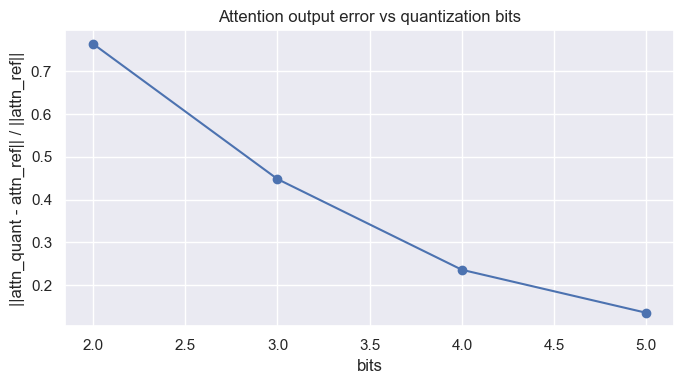

In [12]:
# accuracy vs bits — relative error of attention output
torch.manual_seed(0)
L1, B1, H1, T1, D1 = 1, 1, 4, 128, 128
K1 = torch.randn(B1, H1, T1, D1, device=DEVICE, dtype=DTYPE)
V1 = torch.randn(B1, H1, T1, D1, device=DEVICE, dtype=DTYPE)
Q1 = torch.randn(B1, H1, 16, D1, device=DEVICE, dtype=DTYPE)

ref = F.softmax((Q1 @ K1.transpose(-1, -2)) / math.sqrt(D1), dim=-1) @ V1

results = []
for bits in (2, 3, 4, 5):
    cache = TurboQuantKVCache(num_layers=L1, batch_size=B1, num_heads=H1,
                              max_seq_len=T1, head_dim=D1,
                              bits=bits, m=D1, seed=42, device=DEVICE, dtype=DTYPE)
    cache.update(0, K1, V1)
    out = cache.attention(0, Q1, causal=False)
    err = ((out - ref).norm() / ref.norm()).item()
    results.append((bits, err))
    print(f"bits={bits}  rel err={err:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
bs, errs = zip(*results)
ax.plot(bs, errs, marker="o")
ax.set_xlabel("bits")
ax.set_ylabel("||attn_quant - attn_ref|| / ||attn_ref||")
ax.set_title("Attention output error vs quantization bits")
plt.tight_layout()
plt.show()

## `TurboAttention`: drop-in replacement for HF MHA

Wraps an existing HF attention module so we keep its `c_attn` / `c_proj` projections (and weights), but swap out the K/V storage + softmax-attention math for our `TurboQuantKVCache`.

This implementation targets `GPT2Attention` (no RoPE, simple `c_attn` combined QKV projection — easiest demo). For RoPE-using models (Llama, Qwen, …) you'd apply the rotary embedding to K *before* writing to the cache, since the rotary phase has to be baked in for the inner-product estimator to make sense.

The cache is **shared across all layers** in the model and indexed by `layer_idx`, so installing it across a 12-layer GPT-2 still uses one preallocated buffer set.

In [13]:
import torch.nn as nn


class TurboAttention(nn.Module):
    """Wraps an HF GPT2Attention. Reuses its projections, replaces the K/V cache + SDPA
    path with a shared TurboQuantKVCache.

    Does the head reshape inline (newer transformers dropped `_split_heads`/`_merge_heads`).
    """

    def __init__(self, original_attn: nn.Module, cache: TurboQuantKVCache, layer_idx: int):
        super().__init__()
        self.original = original_attn
        self.cache = cache
        self.layer_idx = layer_idx

    def forward(self, hidden_states, *args, **kwargs):
        a = self.original
        B, T, _ = hidden_states.shape
        H, D = a.num_heads, a.head_dim

        qkv = a.c_attn(hidden_states)                      # [B, T, 3*embed]
        q, k, v = qkv.split(a.split_size, dim=2)
        # [B, T, embed] -> [B, T, H, D] -> [B, H, T, D]
        q = q.view(B, T, H, D).transpose(1, 2)
        k = k.view(B, T, H, D).transpose(1, 2)
        v = v.view(B, T, H, D).transpose(1, 2)

        self.cache.update(self.layer_idx, k, v)
        out = self.cache.attention(self.layer_idx, q, causal=True)   # [B, H, T, D]

        # [B, H, T, D] -> [B, T, H*D]
        out = out.transpose(1, 2).contiguous().view(B, T, H * D)
        out = a.c_proj(out)
        out = a.resid_dropout(out)

        return (out, None)  # (attn_output, attn_weights or present)


def install_turbo_attention_gpt2(gpt2_model: nn.Module, cache: TurboQuantKVCache) -> None:
    """Replace each GPT2Attention with a TurboAttention. The cache is shared across layers."""
    for i, block in enumerate(gpt2_model.transformer.h):
        block.attn = TurboAttention(block.attn, cache, layer_idx=i)

## End-to-end: swap MHA in GPT-2

Loads `gpt2` (12 layers × 12 heads × 64 head-dim), installs `TurboAttention` across all blocks, runs a single forward pass on a long prompt, and reports:

1. KV cache footprint vs the canonical fp16 K+V baseline.
2. Logit fidelity (cosine similarity + top-1 token agreement) against the un-quantized model.

If `transformers` isn't installed (`pip install transformers`), the cell just prints an install hint.

In [27]:
bits = 5
m_scale = 2

try:
    from transformers import GPT2LMHeadModel, GPT2Tokenizer
    HAS_TRANSFORMERS = True
except ImportError:
    HAS_TRANSFORMERS = False
    print("Install transformers to run this demo:  pip install transformers")

if HAS_TRANSFORMERS:
    model_name = "gpt2"
    tok = GPT2Tokenizer.from_pretrained(model_name)
    model = GPT2LMHeadModel.from_pretrained(model_name).to(DEVICE).eval()
    cfg = model.config
    head_dim = cfg.n_embd // cfg.n_head

    prompt = ("The quick brown fox jumps over the lazy dog. "
              "She sells sea shells by the sea shore. ") * 20
    input_ids = tok(prompt, return_tensors="pt").input_ids.to(DEVICE)
    Bm, Tm = input_ids.shape

    # 1) reference logits with original attention
    with torch.no_grad():
        ref_logits = model(input_ids, use_cache=False).logits

    # 2) swap MHA modules and re-run
    cache = TurboQuantKVCache(
        num_layers=cfg.n_layer, batch_size=Bm, num_heads=cfg.n_head,
        max_seq_len=Tm, head_dim=head_dim,
        bits=bits, m=m_scale * head_dim, seed=42, device=DEVICE, dtype=DTYPE,
    )
    install_turbo_attention_gpt2(model, cache)
    cache.reset()
    with torch.no_grad():
        quant_logits = model(input_ids, use_cache=False).logits

    # 3) cache footprint vs fp16 K+V baseline
    fp16_bytes = 2 * cfg.n_layer * Bm * cfg.n_head * Tm * head_dim * 2  # K+V * fp16
    quant_bytes = cache.bytes_total()
    print(f"prompt tokens             : {Tm}")
    print(f"layers x heads x head_dim : {cfg.n_layer} x {cfg.n_head} x {head_dim}")
    print(f"fp16 KV cache             : {fp16_bytes / 1024:.1f} KiB")
    print(f"TurboQuant KV cache       : {quant_bytes / 1024:.1f} KiB")
    print(f"compression ratio         : {fp16_bytes / quant_bytes:.2f}x")
    print(f"bytes / token / layer     : fp16={fp16_bytes // (cfg.n_layer * Tm)}  "
          f"turbo={quant_bytes // (cfg.n_layer * Tm)}")

    # 4) logit fidelity
    cos = F.cosine_similarity(ref_logits, quant_logits, dim=-1).mean()
    top1_match = (ref_logits.argmax(-1) == quant_logits.argmax(-1)).float().mean()
    top5_ref = ref_logits.topk(5, dim=-1).indices
    top5_quant = quant_logits.topk(5, dim=-1).indices
    top5_overlap = ((top5_ref.unsqueeze(-1) == top5_quant.unsqueeze(-2))
                    .any(dim=-1).float().mean())
    print(f"\nlogit cos sim             : {cos.item():.4f}")
    print(f"top-1 token agreement     : {top1_match.item() * 100:.1f}%")
    print(f"top-5 token overlap       : {top5_overlap.item() * 100:.1f}%")

    ref_log_probs = F.log_softmax(ref_logits, dim=-1)
    quant_log_probs = F.log_softmax(quant_logits, dim=-1)
    ref_probs = ref_log_probs.exp()
    kl = (ref_probs * (ref_log_probs - quant_log_probs)).sum(dim=-1)
    print(f"mean KL(ref || quant): {kl.mean().item():.4f}")
    print(f"max  KL(ref || quant): {kl.max().item():.4f}")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 8383.40it/s]


prompt tokens             : 381
layers x heads x head_dim : 12 x 12 x 64
fp16 KV cache             : 13716.0 KiB
TurboQuant KV cache       : 5357.8 KiB
compression ratio         : 2.56x
bytes / token / layer     : fp16=3072  turbo=1200

logit cos sim             : 0.9713
top-1 token agreement     : 99.7%
top-5 token overlap       : 93.8%
mean KL(ref || quant): 0.0014
max  KL(ref || quant): 0.0555


Top 10 positions by KL: tensor([1.5469, 1.2925, 0.7303, 0.6868, 0.5457, 0.3182, 0.2441, 0.2341, 0.2165,
        0.1779], device='mps:0')
% of total KL from top 5%: 55.01%


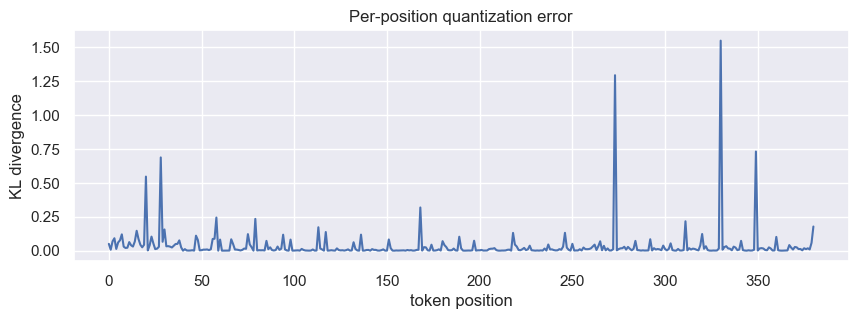

In [18]:
positions_kl = kl.squeeze(0)  # [T]
print(f"Top 10 positions by KL: {positions_kl.topk(10).values}")
print(f"% of total KL from top 5%: {positions_kl.topk(int(len(positions_kl)*0.05)).values.sum() / positions_kl.sum():.2%}")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 3))
plt.plot(positions_kl.cpu().numpy())
plt.xlabel("token position")
plt.ylabel("KL divergence")
plt.title("Per-position quantization error")
plt.show()

In [19]:
# Find positions with high KL
high_kl_positions = (kl.squeeze(0) > 0.3).nonzero(as_tuple=True)[0]
print(f"High-KL positions ({len(high_kl_positions)}):")
print()

# Decode the tokens at those positions
for pos in high_kl_positions:
    pos = pos.item()
    token_id = input_ids[0, pos].item()
    token_str = tok.decode([token_id])
    kl_val = kl.squeeze(0)[pos].item()
    print(f"  pos={pos:>3d}  KL={kl_val:.3f}  token={repr(token_str)}")

# Also look at K/V norms for those positions
# (you'll need to capture these during the forward pass; quick way:
#  reach into the cache after the run)
print(f"\nK norms at high-KL positions vs typical:")
all_k_norms = cache.k_norm[0, 0, 0, :381]  # [T] first layer, head 0
print(f"  median K norm overall: {all_k_norms.median().item():.3f}")
print(f"  mean K norm overall:   {all_k_norms.mean().item():.3f}")
print(f"  K norms at spikes:     {all_k_norms[high_kl_positions].tolist()}")

High-KL positions (6):

  pos= 20  KL=0.546  token=' quick'
  pos= 28  KL=0.687  token='.'
  pos=168  KL=0.318  token=' sea'
  pos=273  KL=1.292  token=' lazy'
  pos=330  KL=1.547  token=' lazy'
  pos=349  KL=0.730  token=' lazy'

K norms at high-KL positions vs typical:
  median K norm overall: 9.806
  mean K norm overall:   9.794
  K norms at spikes:     [10.49719524383545, 10.044890403747559, 11.13341999053955, 9.316258430480957, 9.360442161560059, 9.502787590026855]


In [20]:
# At a high-KL position, look at the attention distribution
# (run a forward pass that returns attentions, or hook one layer)

# For each high-KL position p, ask:
# - what's the max attention weight?
# - what does that correspond to (which key)?
# - how does fp16 attention compare?

# Quick proxy: compare softmax temperature at good vs bad positions
import torch.nn.functional as F

# Use ref_logits and quant_logits you already have
high_pos = [273, 330, 349]
low_pos = [100, 200, 250]  # arbitrary low-KL positions

for p in high_pos + low_pos:
    ref_dist = F.softmax(ref_logits[0, p], dim=-1)
    quant_dist = F.softmax(quant_logits[0, p], dim=-1)
    ref_entropy = -(ref_dist * ref_dist.clamp_min(1e-12).log()).sum()
    quant_entropy = -(quant_dist * quant_dist.clamp_min(1e-12).log()).sum()
    ref_top1 = ref_dist.max()
    print(f"pos={p:>3d}  ref_top1={ref_top1.item():.3f}  ref_H={ref_entropy.item():.2f}  "
          f"quant_H={quant_entropy.item():.2f}")

pos=273  ref_top1=0.998  ref_H=0.02  quant_H=0.82
pos=330  ref_top1=0.998  ref_H=0.02  quant_H=0.66
pos=349  ref_top1=0.998  ref_H=0.02  quant_H=0.77
pos=100  ref_top1=0.998  ref_H=0.02  quant_H=0.04
pos=200  ref_top1=0.983  ref_H=0.16  quant_H=0.14
pos=250  ref_top1=0.994  ref_H=0.05  quant_H=0.57
